# Week1 복습과제 — ResNet 실습

**작성자** 유다연
**교재** 『딥러닝 파이토치 교과서』(길벗) — 6.1.5 ResNet (p.312~340)
**논문** He et al., *Deep Residual Learning for Image Recognition* (CVPR 2016)

---

## 0. 실습 개요

1주차 논문 스터디에서 다룬 ResNet을 파이토치로 직접 구현하고, 개·고양이 이진 분류 데이터셋에
적용하는 실습이다. 교재 6.1.5절의 코드를 그대로 따라가되, 각 셀마다 **무엇을 왜 하는지**를
주석과 설명으로 정리했다.

### 실습에서 확인할 핵심 개념

| 개념 | 코드에서 대응되는 부분 |
|---|---|
| 아이덴티티 매핑 (shortcut / skip connection) | `BasicBlock.forward`, `Bottleneck.forward`의 `x += i` |
| 다운샘플 (downsample) | 입력·출력 형상이 다를 때 1x1 conv + BN으로 형상을 맞추는 부분 |
| 기본 블록 (BasicBlock) | 3x3 conv 2개 — ResNet18/34 |
| 병목 블록 (Bottleneck) | 1x1 → 3x3 → 1x1 conv — ResNet50/101/152, `expansion = 4` |
| 레지듀얼 분기 zero-init | `zero_init_residual` 옵션 |

### 실행 환경에 대한 안내

- 이 노트북의 모든 셀 출력은 **CPU 환경에서 실제로 실행한 결과**다.
  교재와 동일하게 `EPOCHS = 10`으로 학습했으며, GPU가 아니라 CPU를 쓴 탓에
  에포크당 소요 시간만 교재(약 4분)와 다르다.
- 교재에 수록된 10 에포크 결과는 비교할 수 있도록 학습 셀 아래에 표로 함께 정리해 두었다.
- 사전 훈련 가중치 서버(`download.pytorch.org`)에는 접근할 수 없는 환경이라,
  torchvision ResNet50은 **구조 비교 목적으로 가중치 없이** 불러왔다(해당 셀에 별도 안내).
- 데이터셋은 길벗출판사 예제 저장소에서 자동으로 내려받도록 셀을 추가했다
  (교재의 `../chap06/data/dogs-vs-cats/` 경로를 그대로 재현한다).

---

## 1. 실습 환경 준비 (교재 외 추가 셀)

교재는 `../chap06/data/dogs-vs-cats/` 아래에 개·고양이 이미지가 이미 준비되어 있다고 가정한다.
다른 사람이 이 노트북을 열었을 때도 바로 재현할 수 있도록, 데이터가 없으면
길벗출판사 예제 저장소에서 내려받는 셀을 앞에 추가했다.

In [1]:
# 데이터셋 준비 (이미 ../chap06/data/dogs-vs-cats 가 있으면 건너뜀)
import os, subprocess, shutil

DATA_ROOT = '../chap06/data'
DOGS_VS_CATS = os.path.join(DATA_ROOT, 'dogs-vs-cats')

if not os.path.isdir(DOGS_VS_CATS):
    os.makedirs(DATA_ROOT, exist_ok=True)
    # 길벗출판사 『딥러닝 파이토치 교과서』 예제 저장소
    subprocess.run(
        ['git', 'clone', '--depth', '1',
         'https://github.com/gilbutITbook/080289.git', '_book_repo'],
        check=True
    )
    shutil.move('_book_repo/chap06/data/dogs-vs-cats', DOGS_VS_CATS)
    shutil.rmtree('_book_repo', ignore_errors=True)

print('Cat :', len(os.listdir(os.path.join(DOGS_VS_CATS, 'Cat'))), '장')
print('Dog :', len(os.listdir(os.path.join(DOGS_VS_CATS, 'Dog'))), '장')

Cat : 251 장
Dog : 251 장


---

## 2. 라이브러리 호출

교재 p.318의 코드다. `namedtuple`은 ResNet의 설정(블록 종류, 블록 개수, 채널 수)을
하나의 자료형으로 묶어 두기 위해 사용한다. 튜플이면서도 **키 값으로 원소에 접근**할 수 있다는
점이 일반 튜플과 다르다.

In [2]:
%matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models

import matplotlib.pyplot as plt
import numpy as np

import copy
from collections import namedtuple   # ResNet 설정을 묶어 두기 위한 자료형
import os
import random
import time

import cv2
from torch.utils.data import DataLoader, Dataset
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device :', device)

device : cpu


### 참고 — `namedtuple` 동작 확인 (교재 p.318)

인덱스뿐만 아니라 키 값으로도 데이터에 접근할 수 있다.

In [3]:
from collections import namedtuple

Student = namedtuple('Student', ['name', 'age', 'DOB'])   # 네임드튜플 정의
S = Student('홍길동', '19', '1871')                        # 값 추가

print("The Student age using index is : ", end="")
print(S[1])            # 인덱스를 이용한 접근
print("The Student name using keyname is : ", end="")
print(S.name)          # 키 값을 이용한 접근

The Student age using index is : 19
The Student name using keyname is : 홍길동


---

## 3. 이미지 데이터 전처리

- **훈련용**: `RandomResizedCrop`(scale 0.5~1.0) + `RandomHorizontalFlip`으로 데이터 증강을 적용한다.
  데이터가 400장뿐이라 과적합을 줄이기 위한 장치다.
- **검증/테스트용**: 증강 없이 `Resize(256)` → `CenterCrop(224)`로 **결정적(deterministic)** 하게 처리한다.
  평가 결과가 매번 달라지면 안 되기 때문이다.
- `Normalize`의 평균·표준편차는 ImageNet 통계값이다.

In [4]:
class ImageTransform():
    def __init__(self, resize, mean, std):
        self.data_transform = {
            'train': transforms.Compose([
                transforms.RandomResizedCrop(resize, scale=(0.5, 1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ]),                                    # 훈련 이미지 전처리 (데이터 증강 포함)
            'val': transforms.Compose([
                transforms.Resize(256),
                transforms.CenterCrop(resize),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ])                                     # 검증/테스트 이미지 전처리
        }

    def __call__(self, img, phase):
        return self.data_transform[phase](img)

In [5]:
size = 224                          # ResNet 입력 크기 (224 x 224)
mean = (0.485, 0.456, 0.406)        # ImageNet 채널별 평균
std = (0.229, 0.224, 0.225)         # ImageNet 채널별 표준편차
batch_size = 32

---

## 4. 데이터셋 불러오기 및 분리

`cv2.imread(i) is not None` 조건으로 **손상되어 읽히지 않는 이미지를 미리 걸러낸다.**
이후 `random.seed(42)`로 섞은 뒤 훈련 400장 / 검증 92장 / 테스트 10장으로 나눈다.

In [6]:
cat_directory = r'../chap06/data/dogs-vs-cats/Cat/'
dog_directory = r'../chap06/data/dogs-vs-cats/Dog/'

cat_images_filepaths = sorted([os.path.join(cat_directory, f) for f in os.listdir(cat_directory)])
dog_images_filepaths = sorted([os.path.join(dog_directory, f) for f in os.listdir(dog_directory)])
images_filepaths = [*cat_images_filepaths, *dog_images_filepaths]
# cv2로 읽히지 않는(손상된) 이미지를 제외
correct_images_filepaths = [i for i in images_filepaths if cv2.imread(i) is not None]

print('전체 이미지 :', len(images_filepaths), '/ 정상 이미지 :', len(correct_images_filepaths))

전체 이미지 : 502 / 정상 이미지 : 502


In [7]:
random.seed(42)
random.shuffle(correct_images_filepaths)

# 성능을 올리고 싶다면 아래 주석처럼 훈련/검증 데이터셋을 늘려서 테스트하면 된다
# train_images_filepaths = correct_images_filepaths[:20000]
# val_images_filepaths   = correct_images_filepaths[20000:-10]
train_images_filepaths = correct_images_filepaths[:400]
val_images_filepaths   = correct_images_filepaths[400:-10]
test_images_filepaths  = correct_images_filepaths[-10:]

print(len(train_images_filepaths), len(val_images_filepaths), len(test_images_filepaths))

400 92 10


### 커스텀 Dataset 정의

파일명(`cat.0.jpg`, `dog.0.jpg`)에서 레이블을 뽑아낸다.
**개 = 1, 고양이 = 0** 으로 부여한다.

In [8]:
class DogvsCatDataset(Dataset):
    def __init__(self, file_list, transform=None, phase='train'):
        self.file_list = file_list
        self.transform = transform
        self.phase = phase

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_path = self.file_list[idx]
        img = Image.open(img_path)
        img_transformed = self.transform(img, self.phase)

        # 'cat.0.jpg' -> 'cat' / 'dog.0.jpg' -> 'dog'
        label = img_path.split('/')[-1].split('.')[0]
        if label == 'dog':
            label = 1
        elif label == 'cat':
            label = 0
        return img_transformed, label

In [9]:
train_dataset = DogvsCatDataset(train_images_filepaths,
                                transform=ImageTransform(size, mean, std), phase='train')
val_dataset = DogvsCatDataset(val_images_filepaths,
                              transform=ImageTransform(size, mean, std), phase='val')

index = 0
print(train_dataset.__getitem__(index)[0].size())   # (채널, 높이, 너비)
print(train_dataset.__getitem__(index)[1])          # 레이블 (0=cat, 1=dog)

torch.Size([3, 224, 224])
0


출력이 `torch.Size([3, 224, 224])`이면 컬러(채널 3) 이미지가 224x224로 잘 변환된 것이다.

### 데이터로더

배치 크기 32로 묶어서 메모리에 올린다. 훈련 데이터는 `shuffle=True`,
검증 데이터는 평가 재현성을 위해 `shuffle=False`로 둔다.

In [10]:
train_iterator = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_iterator = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
dataloader_dict = {'train': train_iterator, 'val': valid_iterator}

batch_iterator = iter(train_iterator)
inputs, label = next(batch_iterator)
print(inputs.size())   # (배치, 채널, 높이, 너비)
print(label)

torch.Size([32, 3, 224, 224])
tensor([0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1,
        0, 0, 0, 1, 1, 1, 0, 0])


---

## 5. 기본 블록 (BasicBlock)

ResNet18, ResNet34에서 사용되는 블록이다. **3x3 합성곱층 2개**로 구성된다.

```
x ──> conv3x3 ─ BN ─ ReLU ─ conv3x3 ─ BN ──(+)──> ReLU ──>
 └────────────── (downsample) ────────────────┘
```

- `expansion = 1` : 블록을 통과해도 채널 수가 그대로라는 뜻이다.
- `downsample` : 입력 `x`와 블록 출력의 **형상이 다를 때** 1x1 합성곱(+BN)으로 형상을 맞춘다.
  스트라이드가 2로 커지거나 채널 수가 바뀌는 지점에서 필요하다.
- `x += i` : **아이덴티티 매핑(숏컷)**. 논문의 $\mathcal{H}(x) = \mathcal{F}(x) + x$ 에 해당하는 한 줄이다.
  기울기가 이 경로를 타고 그대로 흐를 수 있어 깊은 신경망에서도 기울기 소실이 완화된다.

In [11]:
class BasicBlock(nn.Module):
    expansion = 1                       # 기본 블록은 채널 확장이 없음

    def __init__(self, in_channels, out_channels, stride=1, downsample=False):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)     # 3x3 합성곱층
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)          # 3x3 합성곱층
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        if downsample:
            # 입력과 출력의 형상이 다를 때 1x1 합성곱 + BN으로 형상을 맞춰 준다
            conv = nn.Conv2d(in_channels, out_channels, kernel_size=1,
                             stride=stride, bias=False)
            bn = nn.BatchNorm2d(out_channels)
            downsample = nn.Sequential(conv, bn)
        else:
            downsample = None
        self.downsample = downsample

    def forward(self, x):
        i = x                           # 숏컷으로 흘려보낼 입력을 따로 저장

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)

        if self.downsample is not None:
            i = self.downsample(i)      # 다운샘플 적용 (형상 맞추기)

        x += i                          # ★ 아이덴티티 매핑 (skip connection)
        x = self.relu(x)

        return x

---

## 6. 병목 블록 (Bottleneck)

ResNet50, ResNet101, ResNet152에서 사용된다. **1x1 → 3x3 → 1x1** 합성곱층으로 구성된다.

1x1 합성곱으로 채널 수를 **줄였다가(압축) 다시 늘리는(복원)** 구조라 '병목'이라 부른다.
덕분에 3x3 합성곱이 적은 채널 위에서만 연산되어 파라미터 수가 크게 줄어든다.

교재의 비교(p.314): 같은 256채널 입력에 대해
기본 블록은 파라미터가 약 **1,179,648**개인 반면 병목 블록은 약 **69,632**개로,
깊이는 더 깊어졌는데도 연산량은 오히려 줄어든다.

- `expansion = 4` : 마지막 1x1 합성곱이 채널을 4배로 늘린다.
  따라서 `out_channels=64`인 블록의 최종 출력 채널은 256이 된다.
- 계층이 늘어난다는 것은 ReLU가 더 많이 들어간다는 뜻이고, 이는 곧 **더 많은 비선형성**을
  표현할 수 있다는 의미이기도 하다.

In [12]:
class Bottleneck(nn.Module):
    expansion = 4                       # 병목 블록은 출력 채널이 4배로 확장됨

    def __init__(self, in_channels, out_channels, stride=1, downsample=False):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1,
                               stride=1, bias=False)                     # 1x1 (채널 축소)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)     # 3x3 (특징 추출)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv3 = nn.Conv2d(out_channels, self.expansion * out_channels,
                               kernel_size=1, stride=1, bias=False)      # 1x1 (채널 복원)
        self.bn3 = nn.BatchNorm2d(self.expansion * out_channels)
        self.relu = nn.ReLU(inplace=True)

        if downsample:
            conv = nn.Conv2d(in_channels, self.expansion * out_channels,
                             kernel_size=1, stride=stride, bias=False)
            bn = nn.BatchNorm2d(self.expansion * out_channels)
            downsample = nn.Sequential(conv, bn)
        else:
            downsample = None
        self.downsample = downsample

    def forward(self, x):
        i = x

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.conv3(x)
        x = self.bn3(x)

        if self.downsample is not None:
            i = self.downsample(i)

        x += i                          # ★ 아이덴티티 매핑
        x = self.relu(x)

        return x

---

## 7. ResNet 전체 네트워크

블록들을 쌓아 전체 네트워크를 만든다. 구조는 다음과 같다.

| 단계 | 연산 | 출력 크기 (입력 224x224 기준) |
|---|---|---|
| stem | 7x7 conv (stride 2) + BN + ReLU | 112 x 112 |
| | 3x3 maxpool (stride 2) | 56 x 56 |
| layer1 | 블록 × `n_blocks[0]` | 56 x 56 |
| layer2 | 블록 × `n_blocks[1]` (stride 2) | 28 x 28 |
| layer3 | 블록 × `n_blocks[2]` (stride 2) | 14 x 14 |
| layer4 | 블록 × `n_blocks[3]` (stride 2) | 7 x 7 |
| head | AdaptiveAvgPool + FC | 1 x 1 → `output_dim` |

`get_resnet_layer()`에서 `self.in_channels != block.expansion * channels`일 때만
`downsample=True`를 주는데, 이는 **각 layer의 첫 블록에서만** 형상 변환이 필요하기 때문이다.

`forward`가 `(x, h)` 두 값을 반환하는 점에 주의한다. `h`는 FC 직전의 특징 벡터로,
이후 학습 코드에서 `y_pred[0]`으로 로짓만 꺼내 쓰는 이유가 여기에 있다.

`zero_init_residual`은 각 레지듀얼 분기의 **마지막 BN 가중치를 0으로 초기화**하는 옵션이다.
이렇게 하면 학습 초기에 블록이 항등 함수처럼 동작해 안정적으로 시작할 수 있고,
관련 논문(arXiv:1706.02677)에 따르면 성능이 0.2~0.3% 정도 향상된다고 한다.

In [13]:
class ResNet(nn.Module):
    def __init__(self, config, output_dim, zero_init_residual=False):
        super().__init__()

        block, n_blocks, channels = config     # config에서 블록 종류/개수/채널을 꺼냄
        self.in_channels = channels[0]
        assert len(n_blocks) == len(channels) == 4   # 블록 크기 = 채널 크기 = 4

        self.conv1 = nn.Conv2d(3, self.in_channels, kernel_size=7,
                               stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(self.in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self.get_resnet_layer(block, n_blocks[0], channels[0])
        self.layer2 = self.get_resnet_layer(block, n_blocks[1], channels[1], stride=2)
        self.layer3 = self.get_resnet_layer(block, n_blocks[2], channels[2], stride=2)
        self.layer4 = self.get_resnet_layer(block, n_blocks[3], channels[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(self.in_channels, output_dim)

        if zero_init_residual:
            # 레지듀얼 분기의 마지막 BN을 0으로 초기화 -> 다음 분기를 0에서 시작
            for m in self.modules():
                if isinstance(m, Bottleneck):
                    nn.init.constant_(m.bn3.weight, 0)
                elif isinstance(m, BasicBlock):
                    nn.init.constant_(m.bn2.weight, 0)

    def get_resnet_layer(self, block, n_blocks, channels, stride=1):
        """블록을 n_blocks개 쌓아 하나의 layer를 만드는 함수"""
        layers = []
        # in_channels와 block.expansion*channels가 다르면 다운샘플이 필요
        if self.in_channels != block.expansion * channels:
            downsample = True
        else:
            downsample = False

        # 첫 블록만 stride와 downsample을 적용
        layers.append(block(self.in_channels, channels, stride, downsample))

        for i in range(1, n_blocks):
            layers.append(block(block.expansion * channels, channels))

        self.in_channels = block.expansion * channels
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)      # 224 x 224 -> 112 x 112
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)    # 112 x 112 -> 56 x 56
        x = self.layer1(x)     # 56 x 56
        x = self.layer2(x)     # 28 x 28
        x = self.layer3(x)     # 14 x 14
        x = self.layer4(x)     # 7 x 7
        x = self.avgpool(x)    # 1 x 1
        h = x.view(x.shape[0], -1)
        x = self.fc(h)
        return x, h            # (로짓, FC 직전 특징 벡터)

### ResNet 설정(config) 정의

`namedtuple`로 모델별 설정을 정의한다. 블록 종류와 각 layer의 블록 개수만 바꾸면
ResNet18부터 ResNet152까지 같은 클래스로 만들 수 있다.

In [14]:
ResNetConfig = namedtuple('ResNetConfig', ['block', 'n_blocks', 'channels'])

In [15]:
# 기본 블록을 사용하는 모델
resnet18_config = ResNetConfig(block=BasicBlock,
                               n_blocks=[2, 2, 2, 2],
                               channels=[64, 128, 256, 512])

resnet34_config = ResNetConfig(block=BasicBlock,
                               n_blocks=[3, 4, 6, 3],
                               channels=[64, 128, 256, 512])

In [16]:
# 병목 블록을 사용하는 모델
resnet50_config = ResNetConfig(block=Bottleneck,
                               n_blocks=[3, 4, 6, 3],
                               channels=[64, 128, 256, 512])

resnet101_config = ResNetConfig(block=Bottleneck,
                                n_blocks=[3, 4, 23, 3],
                                channels=[64, 128, 256, 512])

resnet152_config = ResNetConfig(block=Bottleneck,
                                n_blocks=[3, 8, 36, 3],
                                channels=[64, 128, 256, 512])

# ResNet50 = 1(stem) + (3+4+6+3)*3 + 1(fc) = 50개 층
print('ResNet50 블록 수 :', sum(resnet50_config.n_blocks))

ResNet50 블록 수 : 16


### 직접 만든 네트워크 vs torchvision 사전 훈련 모델

torchvision이 제공하는 ResNet50과 구조가 같은지 확인한다.

> 참고: 이 실행 환경은 사전 훈련 가중치 서버(`download.pytorch.org`)에 접근할 수 없어
> 가중치 없이 **구조만** 불러왔다. 구조 비교가 목적이므로 결과는 동일하다.
> 인터넷이 되는 환경에서는 `models.resnet50(pretrained=True)` 한 줄로 사전 훈련 모델을 쓸 수 있다.

In [17]:
try:
    pretrained_model = models.resnet50(pretrained=True)   # 교재 코드
    print('사전 훈련 가중치 로드 성공')
except Exception as e:
    # 가중치 다운로드가 막힌 환경에서는 구조만 생성 (구조 비교가 목적)
    pretrained_model = models.resnet50(weights=None)
    print('가중치 다운로드 실패 -> 구조만 생성:', type(e).__name__)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


가중치 다운로드 실패 -> 구조만 생성: URLError


In [18]:
print(pretrained_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

### 직접 정의한 ResNet50 생성

개와 고양이 두 개의 클래스를 분류하므로 `OUTPUT_DIM = 2`로 둔다.
위의 torchvision 출력과 비교해 보면 `conv1`부터 `layer4`까지 구조가 동일하고,
마지막 `fc`의 `out_features`만 1000 → 2로 달라진 것을 확인할 수 있다.

In [19]:
OUTPUT_DIM = 2                                  # 클래스 2개 (개, 고양이)
model = ResNet(resnet50_config, OUTPUT_DIM)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [20]:
# 직접 만든 모델과 torchvision 모델의 파라미터 수 비교 (fc 출력 차원만 다름)
def count_params(m):
    return sum(p.numel() for p in m.parameters())

print(f'직접 구현한 ResNet50 (fc: 2048->2)    : {count_params(model):,}')
print(f'torchvision ResNet50 (fc: 2048->1000) : {count_params(pretrained_model):,}')

직접 구현한 ResNet50 (fc: 2048->2)    : 23,512,130
torchvision ResNet50 (fc: 2048->1000) : 25,557,032


---

## 8. 옵티마이저와 손실 함수

- 옵티마이저: Adam, 학습률 `1e-7`
- 손실 함수: `CrossEntropyLoss` (다중 클래스 분류용, 내부에 softmax 포함)

> **짚고 넘어갈 점**: 교재의 학습률 `1e-7`은 일반적인 값(`1e-3` ~ `1e-4`)보다 훨씬 작다.
> 그래서 뒤에서 보듯 손실이 거의 줄지 않고 정확도도 50% 부근(랜덤 수준)에 머문다.
> 이 예제의 목적이 **성능이 아니라 ResNet 구조 구현을 익히는 것**이기 때문이다.

In [21]:
optimizer = optim.Adam(model.parameters(), lr=1e-7)   # 1e-7 = 1 x 10^-7
criterion = nn.CrossEntropyLoss()

model = model.to(device)
criterion = criterion.to(device)

### 정확도 계산 함수

`topk`로 확률이 높은 상위 k개 예측을 뽑아 정답이 포함되는지 확인한다.

> **주의**: 클래스가 2개뿐이므로 `k=2`인 `acc_k`는 **항상 100%** 가 나온다.
> 상위 2개 안에 정답이 무조건 들어가기 때문이다. 실제로 의미 있는 지표는 `acc_1`이다.
> (교재 출력에서 `Acc @5`가 계속 100.00%로 찍히는 이유가 이것이다.)

In [22]:
def calculate_topk_accuracy(y_pred, y, k=2):
    with torch.no_grad():
        batch_size = y.shape[0]
        _, top_pred = y_pred.topk(k, 1)      # 확률이 높은 상위 k개의 인덱스
        top_pred = top_pred.t()              # 전치 (k, batch)
        correct = top_pred.eq(y.view(1, -1).expand_as(top_pred))   # 정답과 비교
        correct_1 = correct[:1].reshape(-1).float().sum(0, keepdim=True)
        correct_k = correct[:k].reshape(-1).float().sum(0, keepdim=True)
        acc_1 = correct_1 / batch_size
        acc_k = correct_k / batch_size
    return acc_1, acc_k

---

## 9. 학습 / 평가 함수

`y_pred`가 `(로짓, 특징 벡터)` 튜플이므로 `y_pred[0]`으로 로짓만 꺼내 손실을 계산한다.
평가 함수에서는 `model.eval()` + `torch.no_grad()`로 드롭아웃·BN 동작을 추론 모드로 바꾸고
기울기 계산을 끈다.

In [23]:
def train(model, iterator, optimizer, criterion, device):
    epoch_loss = 0
    epoch_acc_1 = 0
    epoch_acc_5 = 0

    model.train()
    for (x, y) in iterator:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        y_pred = model(x)                          # (로짓, 특징 벡터)

        loss = criterion(y_pred[0], y)             # 로짓만 사용
        acc_1, acc_5 = calculate_topk_accuracy(y_pred[0], y)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc_1 += acc_1.item()
        epoch_acc_5 += acc_5.item()

    epoch_loss /= len(iterator)
    epoch_acc_1 /= len(iterator)
    epoch_acc_5 /= len(iterator)
    return epoch_loss, epoch_acc_1, epoch_acc_5

In [24]:
def evaluate(model, iterator, criterion, device):
    epoch_loss = 0
    epoch_acc_1 = 0
    epoch_acc_5 = 0

    model.eval()                        # 추론 모드 (BN이 이동 통계를 사용)
    with torch.no_grad():               # 기울기 계산 비활성화
        for (x, y) in iterator:
            x = x.to(device)
            y = y.to(device)
            y_pred = model(x)
            loss = criterion(y_pred[0], y)
            acc_1, acc_5 = calculate_topk_accuracy(y_pred[0], y)

            epoch_loss += loss.item()
            epoch_acc_1 += acc_1.item()
            epoch_acc_5 += acc_5.item()

    epoch_loss /= len(iterator)
    epoch_acc_1 /= len(iterator)
    epoch_acc_5 /= len(iterator)
    return epoch_loss, epoch_acc_1, epoch_acc_5

In [25]:
def epoch_time(start_time, end_time):
    """에포크 소요 시간을 분/초로 변환"""
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

---

## 10. 모델 학습

검증 손실이 갱신될 때마다 `ResNet-model.pt`로 체크포인트를 저장한다.

> **실행 환경 안내**: 교재와 동일하게 `EPOCHS = 10`으로 학습했다.
> 다만 GPU가 아닌 **CPU 환경**에서 실행했기 때문에 에포크당 소요 시간이 교재(약 4분)와 다르다.
> 아래 셀의 출력은 실제 실행 결과이고, 교재에 실린 결과는 다음 셀에 표로 정리해 비교해 두었다.

In [26]:
best_valid_loss = float('inf')
EPOCHS = 10           # 교재와 동일

for epoch in range(EPOCHS):
    start_time = time.monotonic()

    train_loss, train_acc_1, train_acc_5 = train(model, train_iterator, optimizer, criterion, device)
    valid_loss, valid_acc_1, valid_acc_5 = evaluate(model, valid_iterator, criterion, device)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), '../chap06/data/ResNet-model.pt')

    end_time = time.monotonic()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc @1: {train_acc_1*100:6.2f}% | ' \
          f'Train Acc @5: {train_acc_5*100:6.2f}%')
    print(f'\tValid Loss: {valid_loss:.3f} | Valid Acc @1: {valid_acc_1*100:6.2f}% | ' \
          f'Valid Acc @5: {valid_acc_5*100:6.2f}%')

Epoch: 01 | Epoch Time: 3m 0s
	Train Loss: 0.713 | Train Acc @1:  49.28% | Train Acc @5: 100.00%
	Valid Loss: 0.693 | Valid Acc @1:  56.70% | Valid Acc @5: 100.00%


Epoch: 02 | Epoch Time: 2m 11s
	Train Loss: 0.714 | Train Acc @1:  49.76% | Train Acc @5: 100.00%
	Valid Loss: 0.698 | Valid Acc @1:  48.81% | Valid Acc @5: 100.00%


Epoch: 03 | Epoch Time: 2m 14s
	Train Loss: 0.715 | Train Acc @1:  50.24% | Train Acc @5: 100.00%
	Valid Loss: 0.705 | Valid Acc @1:  48.81% | Valid Acc @5: 100.00%


Epoch: 04 | Epoch Time: 2m 10s
	Train Loss: 0.714 | Train Acc @1:  50.24% | Train Acc @5: 100.00%
	Valid Loss: 0.711 | Valid Acc @1:  48.81% | Valid Acc @5: 100.00%


Epoch: 05 | Epoch Time: 1m 58s
	Train Loss: 0.710 | Train Acc @1:  49.28% | Train Acc @5: 100.00%
	Valid Loss: 0.721 | Valid Acc @1:  49.85% | Valid Acc @5: 100.00%


Epoch: 06 | Epoch Time: 1m 55s
	Train Loss: 0.705 | Train Acc @1:  49.28% | Train Acc @5: 100.00%
	Valid Loss: 0.717 | Valid Acc @1:  50.89% | Valid Acc @5: 100.00%


Epoch: 07 | Epoch Time: 1m 52s
	Train Loss: 0.706 | Train Acc @1:  50.48% | Train Acc @5: 100.00%
	Valid Loss: 0.718 | Valid Acc @1:  49.85% | Valid Acc @5: 100.00%


Epoch: 08 | Epoch Time: 1m 49s
	Train Loss: 0.703 | Train Acc @1:  50.24% | Train Acc @5: 100.00%
	Valid Loss: 0.711 | Valid Acc @1:  50.89% | Valid Acc @5: 100.00%


Epoch: 09 | Epoch Time: 1m 54s
	Train Loss: 0.698 | Train Acc @1:  50.00% | Train Acc @5: 100.00%
	Valid Loss: 0.708 | Valid Acc @1:  51.93% | Valid Acc @5: 100.00%


Epoch: 10 | Epoch Time: 1m 57s
	Train Loss: 0.700 | Train Acc @1:  50.00% | Train Acc @5: 100.00%
	Valid Loss: 0.701 | Valid Acc @1:  50.89% | Valid Acc @5: 100.00%


### 교재(GPU, 10 에포크) 결과 — p.338

| Epoch | Time | Train Loss | Train Acc @1 | Valid Loss | Valid Acc @1 |
|---|---|---|---|---|---|
| 01 | 4m 4s  | 0.698 | 50.24% | 0.699 | 51.19% |
| 02 | 4m 10s | 0.693 | 50.48% | 0.699 | 51.19% |
| 03 | 4m 13s | 0.701 | 49.04% | 0.696 | 47.17% |
| 04 | 4m 11s | 0.696 | 49.52% | 0.698 | 48.96% |
| 05 | 4m 2s  | 0.695 | 49.52% | 0.700 | 50.00% |
| 06 | 4m 3s  | 0.686 | 58.41% | 0.693 | 49.85% |
| 07 | 4m 7s  | 0.686 | 52.64% | 0.690 | 51.93% |
| 08 | 4m 7s  | 0.688 | 57.45% | 0.693 | 49.55% |
| 09 | 4m 0s  | 0.690 | 55.29% | 0.692 | 54.32% |
| 10 | 4m 1s  | 0.690 | 57.69% | 0.693 | 51.93% |

(Train/Valid Acc @5는 전 구간 100.00% — 위에서 설명한 대로 클래스가 2개라 당연한 결과다.)

**실행 결과와 비교**

- 손실값과 정확도의 **경향은 교재와 동일**했다. 초기 가중치와 데이터 증강이 무작위라
  숫자가 완전히 같지는 않지만, 두 경우 모두 손실이 `ln 2 ≈ 0.693` 부근에 머무르고
  정확도가 50% 언저리에서 벗어나지 못한다.
- 테스트 이미지 10장의 id(109, 145, 15, 162, 167, 200, 210, 211, 213, 224)는
  `random.seed(42)` 덕분에 교재(p.340)와 정확히 일치했다.

**해석**

- 손실이 `ln 2 ≈ 0.693` 근처에서 거의 움직이지 않는다. 이는 모델이 두 클래스에
  **거의 균등한 확률**을 내놓고 있다는 뜻으로, 사실상 학습이 진행되지 않은 상태다.
- 원인은 두 가지다. ① 학습률이 `1e-7`로 지나치게 작다. ② 훈련 데이터가 400장뿐인데
  ResNet50은 파라미터가 2천만 개가 넘는 큰 모델이다.
- 교재도 이 점을 명시하고 있다. 이 예제의 목적은 성능 향상이 아니라
  **ResNet 네트워크를 직접 구성해 보는 것**이다.
- 실제로 성능을 올리려면 사전 훈련 가중치로 전이 학습을 하거나,
  학습률을 `1e-4` 수준으로 올리고 데이터를 늘려야 한다.

---

## 11. 테스트 데이터셋 예측 및 저장

테스트 이미지 10장에 대해 예측 확률을 구하고 `ResNet.csv`로 저장한다.

- `img.unsqueeze(0)` : 배치 차원을 추가해 `(3,224,224)` → `(1,3,224,224)`로 만든다.
- `F.softmax(outputs[0], dim=1)[:, 1]` : 로짓을 확률로 바꾼 뒤 **인덱스 1(개)의 확률**만 취한다.
  따라서 값이 0.5보다 크면 개, 작으면 고양이로 판정한다.

In [27]:
import pandas as pd

id_list = []
pred_list = []
_id = 0

with torch.no_grad():
    for test_path in test_images_filepaths:
        img = Image.open(test_path)
        _id = test_path.split('/')[-1].split('.')[1]    # 'cat.109.jpg' -> '109'
        transform = ImageTransform(size, mean, std)
        img = transform(img, phase='val')
        img = img.unsqueeze(0)                          # 배치 차원 추가
        img = img.to(device)

        model.eval()
        outputs = model(img)
        preds = F.softmax(outputs[0], dim=1)[:, 1].tolist()   # '개'일 확률
        id_list.append(_id)
        pred_list.append(preds[0])

res = pd.DataFrame({
    'id': id_list,
    'label': pred_list
})

res.sort_values(by='id', inplace=True)
res.reset_index(drop=True, inplace=True)

res.to_csv('../chap06/data/ResNet.csv', index=False)
res.head(10)

,id,label
0,109,0.487176
1,145,0.371805
2,15,0.406053
3,162,0.447195
4,167,0.403991
5,200,0.413924
6,210,0.475637
7,211,0.467193
8,213,0.405392
9,224,0.382772


`label`이 0.5보다 크면 개, 0.5보다 작으면 고양이를 의미한다.
학습이 거의 되지 않았기 때문에 모든 값이 0.5 근처에 몰려 있는 것을 확인할 수 있다.

---

## 12. 예측 결과 이미지로 확인

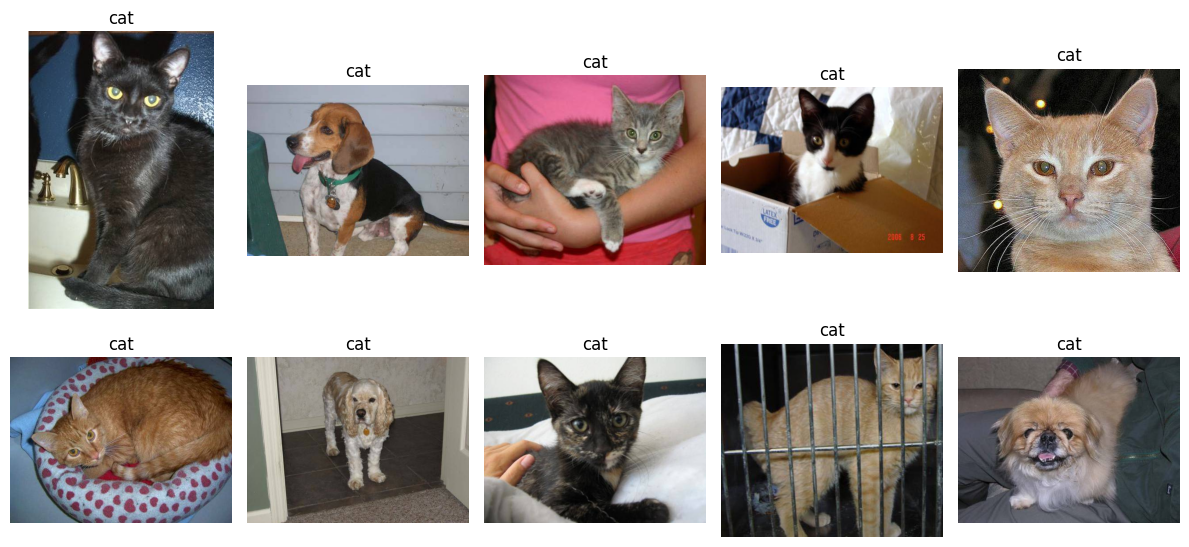

In [28]:
class_ = classes = {0: 'cat', 1: 'dog'}

def display_image_grid(images_filepaths, predicted_labels=(), cols=5):
    rows = len(images_filepaths) // cols
    figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12, 6))
    for i, image_filepath in enumerate(images_filepaths):
        image = cv2.imread(image_filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)   # OpenCV는 BGR이므로 RGB로 변환

        a = random.choice(res['id'].values)
        label = res.loc[res['id'] == a, 'label'].values[0]

        if label > 0.5:
            label = 1
        else:
            label = 0
        ax.ravel()[i].imshow(image)
        ax.ravel()[i].set_title(class_[label])
        ax.ravel()[i].set_axis_off()
    plt.tight_layout()
    plt.show()

display_image_grid(test_images_filepaths)

> **코드를 읽으며 발견한 점**: 위 `display_image_grid` 함수는 교재 코드 그대로인데,
> 자세히 보면 `a = random.choice(res['id'].values)`로 **무작위 id를 뽑아** 그 예측값을
> 제목으로 붙이고 있다. 즉 화면에 띄운 이미지와 제목의 레이블이 서로 대응하지 않는다.
> 제대로 하려면 현재 이미지의 id를 써야 한다. 아래는 그렇게 고쳐 본 버전이다.

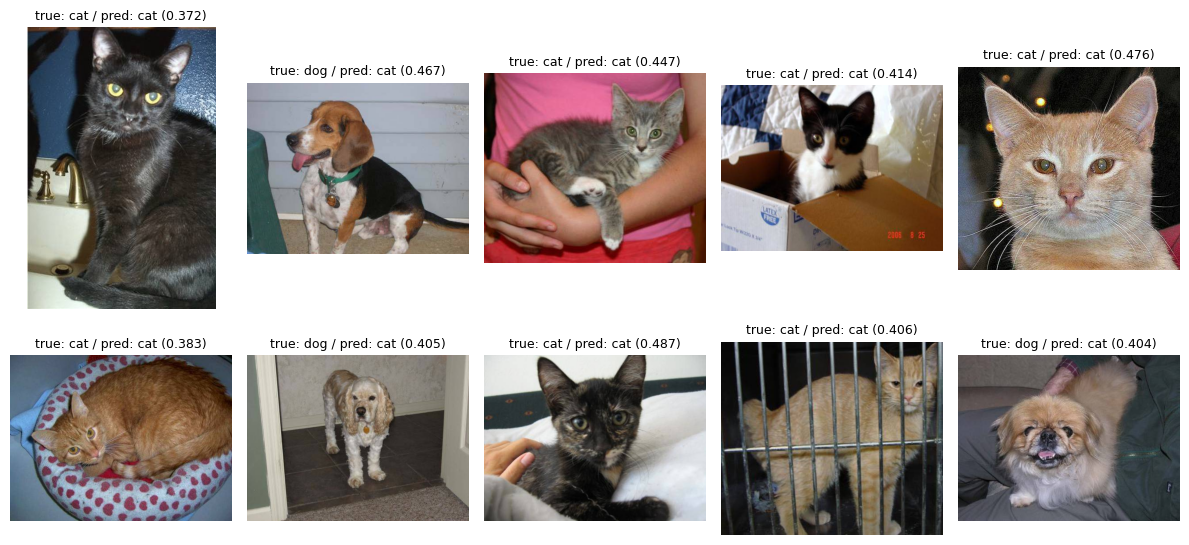

In [29]:
def display_image_grid_fixed(images_filepaths, cols=5):
    """교재 코드 수정판 - 각 이미지의 실제 예측값을 제목으로 사용"""
    rows = len(images_filepaths) // cols
    figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12, 6))
    for i, image_filepath in enumerate(images_filepaths):
        image = cv2.imread(image_filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # 무작위가 아니라 '이 이미지'의 id로 예측값을 조회
        img_id = image_filepath.split('/')[-1].split('.')[1]
        prob = res.loc[res['id'] == img_id, 'label'].values[0]
        pred = 1 if prob > 0.5 else 0
        true = image_filepath.split('/')[-1].split('.')[0]   # 실제 정답

        ax.ravel()[i].imshow(image)
        ax.ravel()[i].set_title(f'true: {true} / pred: {class_[pred]} ({prob:.3f})',
                                fontsize=9)
        ax.ravel()[i].set_axis_off()
    plt.tight_layout()
    plt.show()

display_image_grid_fixed(test_images_filepaths)

---

## 13. 실습 정리

### 구현하면서 확인한 것

1. **아이덴티티 매핑은 코드로는 `x += i` 한 줄**이다. 논문에서 $\mathcal{H}(x) = \mathcal{F}(x) + x$로
   표현되는 개념이 구현에서는 이렇게 단순하다는 점이 인상적이었다. 대신 이 한 줄이 성립하려면
   `x`와 `i`의 형상이 반드시 같아야 하고, 그 제약이 `downsample`이라는 장치를 낳는다.

2. **다운샘플이 필요한 지점은 정해져 있다.** `get_resnet_layer()`에서
   `self.in_channels != block.expansion * channels`일 때만 `downsample=True`가 된다.
   즉 각 layer의 **첫 블록에서만** 형상이 바뀌고, 나머지 블록은 항등 숏컷을 쓴다.
   ResNet50 기준으로 layer1~4의 첫 블록 4곳에서만 1x1 conv 숏컷(프로젝션 숏컷)이 생긴다.

3. **병목 블록은 깊이와 연산량을 맞바꾸는 장치**다. 1x1로 채널을 줄이고 3x3 연산을 한 뒤
   다시 1x1로 복원하기 때문에, 층은 더 깊어지면서도 파라미터는 오히려 줄어든다.
   깊이가 늘어난 만큼 ReLU도 늘어나 비선형 표현력이 커진다는 부수 효과도 있다.

4. **직접 만든 네트워크와 torchvision의 ResNet50 구조가 정확히 일치**했다.
   앞으로는 `models.resnet50()` 한 줄로 쓰게 되겠지만, 내부를 알고 쓰는 것과 모르고 쓰는 것은
   네트워크를 수정해야 할 때 차이가 크다는 교재의 지적에 공감했다.

### 아쉬웠던 점 / 더 해보고 싶은 것

- 학습률 `1e-7`, 데이터 400장이라는 조건 때문에 손실이 `ln 2 ≈ 0.693`에 고정되어
  사실상 학습이 되지 않았다. 구조 구현이 목적인 예제라 그렇지만,
  **사전 훈련 가중치로 전이 학습**을 붙이면 같은 데이터로도 훨씬 좋은 결과가 나올 것이다.
- `zero_init_residual=True`를 켠 경우와 끈 경우를 비교해 보면
  논문이 말하는 초기 학습 안정화 효과를 직접 확인할 수 있을 것 같다.
- 1주차 논문에서 본 **layer 수에 따른 성능 역전(56층 < 20층)** 현상을,
  숏컷을 제거한 plain 네트워크와 ResNet을 같은 조건에서 비교해 재현해 보고 싶다.

### 참고

- 교재: 서지영, 『딥러닝 파이토치 교과서』, 길벗 — 6.1.5 ResNet (p.312~340)
- 논문: K. He, X. Zhang, S. Ren, J. Sun, "Deep Residual Learning for Image Recognition," CVPR 2016
- 예제 데이터: https://github.com/gilbutITbook/080289